In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/cleaned_dataset.csv", index_col=0)

In [4]:
df.columns

Index(['site_name', 'delivery_time', 'production', 'installed_capacity',
       'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m', 'temperature_2m',
       'dewpoint_2m', 'apparent_temperature', 'pressure_msl',
       'surface_pressure', 'precipitation', 'snowfall', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
       'weather_code', 'sunshine_duration', 'latitude', 'longitude',
       'wind_speed_100m_cube', 'wind_shear', 'wind_dir_100m_sin',
       'wind_dir_100m_cos', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'utilization_rate', 'site_Belwind Phase 1', 'site_Mermaid Offshore WP',
       'site_Nobelwind Offshore Windpark', 'site_Norther Offshore WP',
       'site_Northwester 2', 'site_Northwind', 'site_Rentel Offshore WP',
       'site_Seastar Offshore WP', 'site_Thorntonbank - C-Power - Area NE',
       'site_Thorntonbank - C-Power - Area SW', 'is_maintenance',

In [5]:
df.head()

,site_name,delivery_time,production,installed_capacity,wind_speed_10m,wind_speed_100m,wind_gusts_10m,temperature_2m,dewpoint_2m,apparent_temperature,...,site_Northwind,site_Rentel Offshore WP,site_Seastar Offshore WP,site_Thorntonbank - C-Power - Area NE,site_Thorntonbank - C-Power - Area SW,is_maintenance,maint_rolling_sum,is_confirmed_maint,is_curtailment,to_drop_for_training
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,Belwind Phase 1,2023-01-01 00:00:00+00:00,147.7025,171.0,14.603082,19.897738,20.7,12.25,8.85,4.282408,...,False,False,False,False,False,0,NaN,0,0,False
1,Belwind Phase 1,2023-01-01 01:00:00+00:00,146.1775,171.0,16.182089,21.681328,20.8,12.10,8.80,3.290131,...,False,False,False,False,False,0,0.0,0,0,False
2,Belwind Phase 1,2023-01-01 02:00:00+00:00,146.1800,171.0,17.969420,23.809662,24.1,11.85,9.50,2.291797,...,False,False,False,False,False,0,0.0,0,0,False
3,Belwind Phase 1,2023-01-01 03:00:00+00:00,146.5050,171.0,14.792228,19.860010,23.9,11.80,9.85,4.007824,...,False,False,False,False,False,0,0.0,0,0,False
4,Belwind Phase 1,2023-01-01 04:00:00+00:00,146.6950,171.0,15.001333,19.915070,19.7,11.75,9.30,3.694952,...,False,False,False,False,False,0,0.0,0,0,False


In [6]:
def add_lag_rolling_features(df, target_col='utilization_rate'):
    """
    Ajoute LAG et ROLLING features sur les colonnes existantes,
    en s'assurant de ne pas utiliser de données à moins de 12h.
    """
    df = df.copy()
    df['delivery_time'] = pd.to_datetime(df['delivery_time'])
    
    # Création des lags de base
    for lag in [12, 24, 36]:
        df[f'{target_col}_lag_{lag}h'] = df.groupby('site_name')[target_col].shift(lag)
        df[f'wind_100m_lag_{lag}h'] = df.groupby('site_name')['wind_speed_100m'].shift(lag)
    
    # Moyennes et écart-types glissants appliqués sur la donnée décalée de 12h
    for window in [12, 24]:
        # On décale d'abord de 12h (`.shift(12)`), puis on calcule la rolling window
        df[f'{target_col}_rolling_mean_{window}h_lag12'] = df.groupby('site_name')[target_col].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )
        
        df[f'{target_col}_rolling_std_{window}h_lag12'] = df.groupby('site_name')[target_col].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).std()
        )
        
        df[f'wind_100m_rolling_mean_{window}h_lag12'] = df.groupby('site_name')['wind_speed_100m'].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )

        df[f'temp_rolling_mean_{window}h_lag12'] = df.groupby('site_name')['temperature_2m'].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )
        
        df[f'radiation_rolling_mean_{window}h_lag12'] = df.groupby('site_name')['shortwave_radiation'].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )
    
    # Évolution de la production (tendances) calculées uniquement avec des données >= 12h
    df[f'{target_col}_change_12h_24h'] = df[f'{target_col}_lag_12h'] - df[f'{target_col}_lag_24h']
    df[f'{target_col}_change_24h_36h'] = df[f'{target_col}_lag_24h'] - df[f'{target_col}_lag_36h']
    
    df['wind_change_12h_24h'] = df['wind_100m_lag_12h'] - df['wind_100m_lag_24h']
    
    df['day_of_week'] = df['delivery_time'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    return df

df_featured = add_lag_rolling_features(df, target_col='utilization_rate')

print(f"Colonnes avant : {len(df.columns)}")
print(f"Colonnes après : {len(df_featured.columns)}")
print(f"\nNouvelles colonnes ajoutées : {len(df_featured.columns) - len(df.columns)}")
print(f"NaN introduits : {df_featured.isnull().sum().sum()}")

Colonnes avant : 49
Colonnes après : 70

Nouvelles colonnes ajoutées : 21
NaN introduits : 3520


In [7]:
df_featured['utilization_rate_24h'] = df_featured.groupby('site_name')['utilization_rate'].shift(-24)

On rajoute les données du forecast pendant la période de la prédiction:

In [8]:
df_featured.columns

Index(['site_name', 'delivery_time', 'production', 'installed_capacity',
       'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m', 'temperature_2m',
       'dewpoint_2m', 'apparent_temperature', 'pressure_msl',
       'surface_pressure', 'precipitation', 'snowfall', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
       'weather_code', 'sunshine_duration', 'latitude', 'longitude',
       'wind_speed_100m_cube', 'wind_shear', 'wind_dir_100m_sin',
       'wind_dir_100m_cos', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'utilization_rate', 'site_Belwind Phase 1', 'site_Mermaid Offshore WP',
       'site_Nobelwind Offshore Windpark', 'site_Norther Offshore WP',
       'site_Northwester 2', 'site_Northwind', 'site_Rentel Offshore WP',
       'site_Seastar Offshore WP', 'site_Thorntonbank - C-Power - Area NE',
       'site_Thorntonbank - C-Power - Area SW', 'is_maintenance',

In [9]:
# weather_cols = [
#     'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m',
#     'temperature_2m', 'dewpoint_2m', 'apparent_temperature',
#     'pressure_msl', 'surface_pressure', 'precipitation', 'snowfall',
#     'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
#     'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
#     'sunshine_duration', 'wind_speed_100m_cube', 'wind_shear',
#     'wind_dir_100m_sin', 'wind_dir_100m_cos'
# ]

# for col in weather_cols:
#     if col in df_featured.columns and f'{col}_24h_ahead' not in df_featured.columns:
#         df_featured[f'{col}_24h_ahead'] = df_featured.groupby('site_name')[col].shift(-24)

In [10]:
df_model = df_featured.dropna().copy()
df_model = df_model.sort_values('delivery_time').reset_index(drop=True)

print(f"Lignes conservées : {len(df_model)}/{len(df_featured)}")

features_to_exclude = [
    'site_name', 'delivery_time', 'production', 'to_drop_for_training',
    'utilization_rate_24h', 'utilization_rate'
    # # On enlève la météo observée (sans _24h_ahead):
    # 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m',
    # 'temperature_2m', 'dewpoint_2m', 'apparent_temperature',
    # 'pressure_msl', 'surface_pressure', 'precipitation', 'snowfall',
    # 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    # 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
    # 'sunshine_duration', 'wind_speed_100m_cube', 'wind_shear',
    # 'wind_dir_100m_sin', 'wind_dir_100m_cos',
]

X = df_model.drop(columns=features_to_exclude)
y = df_model['utilization_rate_24h']

print(f"\nFeatures sélectionnées : {X.shape[1]}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print(f"\nData types:\n{X.dtypes.value_counts()}")

Lignes conservées : 228969/229569

Features sélectionnées : 65
X shape: (228969, 65)
y shape: (228969,)

Data types:
float64    50
bool       10
int64       4
int32       1
Name: count, dtype: int64


In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.4,
    shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    shuffle=False
)

print(f"\nTrain size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val size:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test size:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")


feature_cols = [col for col in df_model.columns if col not in features_to_exclude]

print(f"\nFeatures sélectionnées: {len(feature_cols)}")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   | y_test:  {y_test.shape}")


Train size: 137381 (60.0%)
Val size:   45794 (20.0%)
Test size:  45794 (20.0%)

Features sélectionnées: 65
X_train: (137381, 65) | y_train: (137381,)
X_val:   (45794, 65)   | y_val:   (45794,)
X_test:  (45794, 65)   | y_test:  (45794,)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [13]:
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=1,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)], # Evaluation sur le set de validation
    verbose=10
)

[0]	validation_0-rmse:0.33471
[10]	validation_0-rmse:0.32175
[20]	validation_0-rmse:0.32586
[29]	validation_0-rmse:0.32691


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [14]:
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

In [15]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"\nTrain set:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")


Train set:
  RMSE: 0.2528
  MAE:  0.2214
  R²:   0.4504


In [16]:
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"\nValidation set:")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  MAE:  {val_mae:.4f}")
print(f"  R²:   {val_r2:.4f}")



Validation set:
  RMSE: 0.3209
  MAE:  0.2800
  R²:   0.0831


In [17]:
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nTest set:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")


Test set:
  RMSE: 0.3254
  MAE:  0.2841
  R²:   0.1083


In [18]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(20).to_string())


                             feature  importance
2                    wind_speed_100m    0.077489
29                         month_cos    0.075982
1                     wind_speed_10m    0.048890
8                   surface_pressure    0.039543
59  radiation_rolling_mean_24h_lag12    0.039242
3                     wind_gusts_10m    0.038234
14                  cloud_cover_high    0.029412
24                 wind_dir_100m_sin    0.029148
25                 wind_dir_100m_cos    0.028606
28                         month_sin    0.028301
23                        wind_shear    0.026227
58       temp_rolling_mean_24h_lag12    0.025681
11                       cloud_cover    0.025175
63                       day_of_week    0.024402
53       temp_rolling_mean_12h_lag12    0.024325
7                       pressure_msl    0.021234
5                        dewpoint_2m    0.021113
6               apparent_temperature    0.020982
49                 wind_100m_lag_36h    0.019882
57  wind_100m_rollin

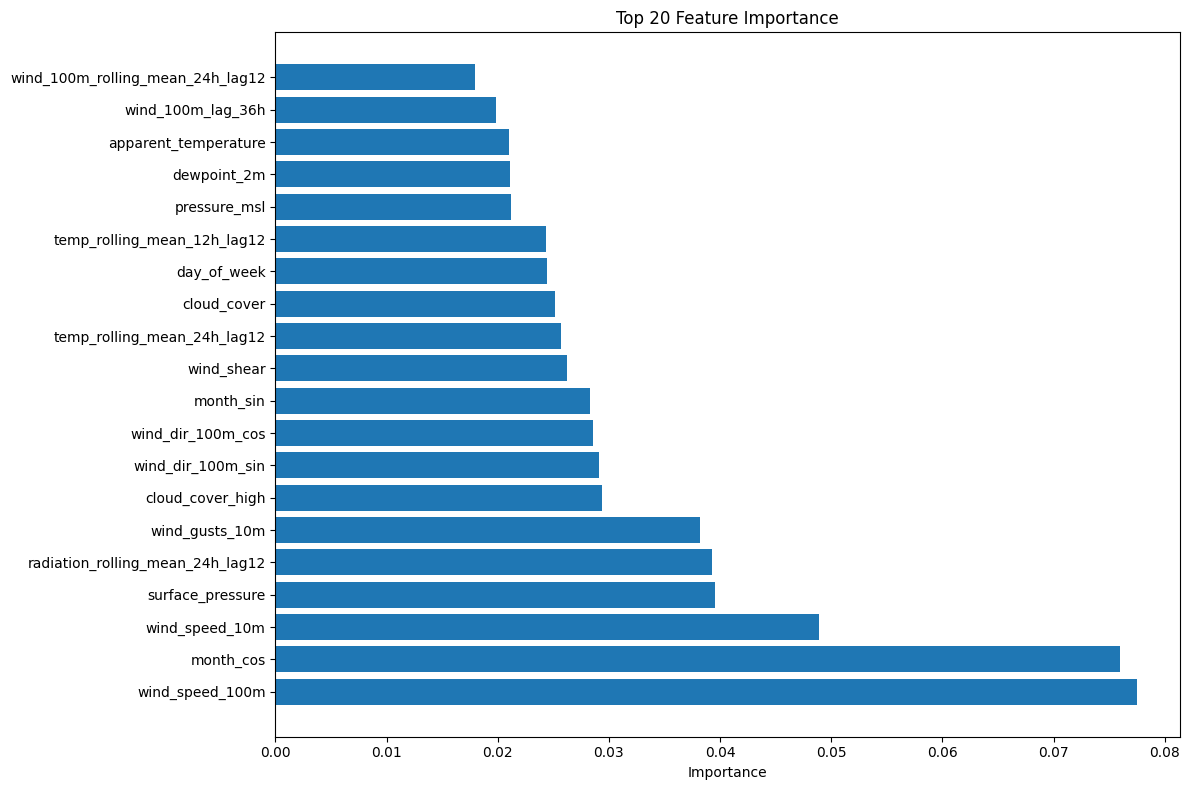

In [19]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()